# SVM

In [1]:
from datetime import datetime
from scipy.sparse import load_npz, hstack, csr_matrix
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import pandas as pd

Se carga dataset.

In [2]:
X_train = load_npz('datasets/X_train.npz')
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_test = load_npz('datasets/X_test.npz')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

X_extra_train.drop(['Email Text Raw'], axis=1, inplace=True)
X_extra_test.drop(['Email Text Raw'], axis=1, inplace=True)

Se estandarizan valores.

In [3]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
scaler_num = StandardScaler(with_mean=False)
scaler_tfidf = StandardScaler(with_mean=False)

tf = ColumnTransformer(transformers=[
    ('bin', 'passthrough', ['has_link', 'domain_dot_high', 'has_suspicious_tags']),
    ('cat', ohe, ['words_count_cat']),
    ('num', scaler_num, ['imperative_verbs_count', 'pronoun_density', 'urgency_markers_count'])
],
remainder='drop')

X_train = scaler_tfidf.fit_transform(X_train)
X_test = scaler_tfidf.transform(X_test)

X_extra_train = tf.fit_transform(X_extra_train)
X_extra_test = tf.transform(X_extra_test)

X_train = hstack([X_train, X_extra_train])
X_test = hstack([X_test, X_extra_test])

Kernel RBF recomendado por la documentación.

In [4]:
svc_model = SVC(kernel='rbf', probability=True)

start_train = datetime.now()
svc_model.fit(X_train, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = svc_model.predict(X_test)
predict_duration = datetime.now() - start_pred

#### Métricas

Se evalúa.

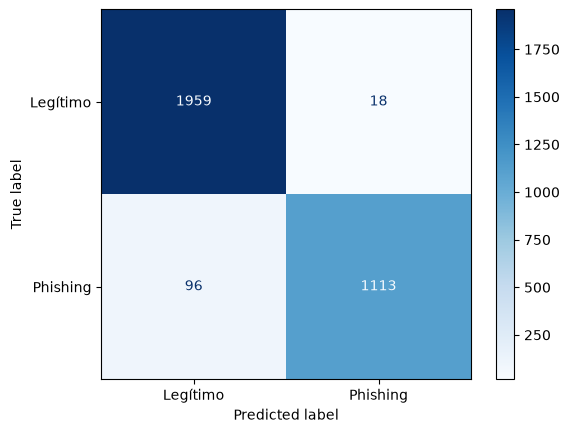

In [5]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [6]:
cm_svc_model = confusion_matrix(y_test, y_pred)
P = cm_svc_model[1, :].sum()
N = cm_svc_model[0, :].sum()
TP = cm_svc_model[1, 1]
TN = cm_svc_model[0, 0]

TPR_svm = TP / P
TNR_svm = TN / N
balanced_accuracy_svm = (TPR_svm + TNR_svm) / 2

precision_svm = precision_score(y_test, y_pred, zero_division=0)
recall_svm = recall_score(y_test, y_pred, zero_division=0)
f1_svm = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_svm:.4f}")
print(f"Precisión:               {precision_svm:.4f}")
print(f"Sensibilidad (Recall):   {TPR_svm:.4f}")
print(f"F1-score:                {f1_svm:.4f}")
print(f"Especificidad:           {TNR_svm:.4f}")
print(f"Recuperación (Recall):   {recall_svm:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.9557
Precisión:               0.9841
Sensibilidad (Recall):   0.9206
F1-score:                0.9513
Especificidad:           0.9909
Recuperación (Recall):   0.9206
Tiempo de entrenamiento: 0:06:52.176386
Tiempo de predicción:    0:00:09.413364


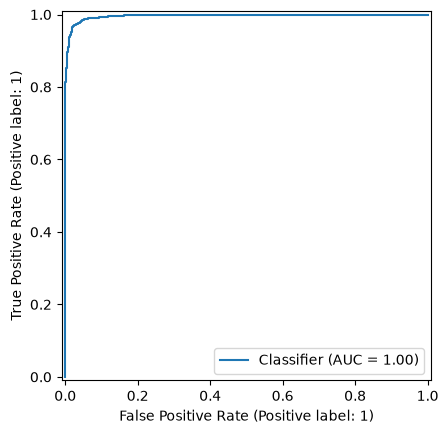

In [7]:
y_scores = svc_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

#### Vectores de soporte por clase

<BarContainer object of 2 artists>

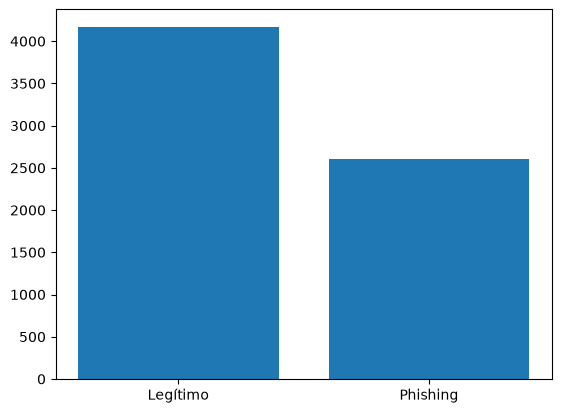

In [8]:
plt.bar(['Legítimo', 'Phishing'], svc_model.n_support_)